# Notebook assumptions

* anaconda and postgres are running via docker-compose containers
* to run on the VM, I created a new docker file to modify the dependencies for sentence_transformers

```
w205@ip-172-31-20-144: ~/docker/clusters/anaconda_postgres_neo4j $ cat dockerfile_project3 
FROM w205_anaconda

RUN pip uninstall -y sentence-transformers transformers torch typing_extensions pyodbc || true \
 && pip install --no-cache-dir \
    "typing_extensions>=4.9" \
    "torch==2.1.2" \
    "transformers==4.38.2" \
    "sentence-transformers==2.6.1"
```

Then, in the docker-compose I updated the following for anaconda

```
w205@ip-172-31-20-144: ~/docker/clusters/anaconda_postgres_neo4j $ cat docker-compose.yml 
...

  anaconda:
    build:
      context: .
      dockerfile: dockerfile_project3
    image: w205_anaconda_project3

...

```

# imports

In [1]:
import csv

import math
import numpy as np
import pandas as pd
import psycopg2
import neo4j
import json
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# postgres support

In [2]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)
cursor = connection.cursor()

In [3]:
def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integers
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)

# neo4j support

In [4]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("neo4j","ucb_mids_w205"))
session = driver.session(database="neo4j")


def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    result = session.run(query, **kwargs)    
    return pd.DataFrame([r.values() for r in result], columns=result.keys())


def my_neo4j_wipe_out_database():
    "wipe out database by deleting all nodes and relationships"
    
    query = "match (node)-[relationship]->() delete node, relationship"
    session.run(query)
    
    query = "match (node) delete node"
    session.run(query)

    
def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.title as movie_title, labels(n) as labels
        order by n.title
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1)-[r]->(n2) 
        return n1.title as movie_title_1, labels(n1) as node_1_labels, 
            type(r) as relationship_type, n2.title as movie_title_2, labels(n2) as node_2_labels
        order by movie_title_1, movie_title_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f'{density:.1f}')
    print("-------------------------")
    
    
def my_neo4j_create_relationship_two_way(from_movie_id, to_movie_id, weight):
    "create relationships two way between two movies with a weight"
    
    query = """
    
    MATCH (from:Movie), 
          (to:Movie)
    WHERE from.id = $from_movie_id and to.id = $to_movie_id
    MERGE (from)-[r1:SIMILAR]->(to)
    MERGE (to)-[r2:SIMILAR]->(from)
    SET r1.weight = $weight,
        r2.weight = $weight
    
    """
    
    session.run(query, from_movie_id=from_movie_id, to_movie_id=to_movie_id, weight=weight)
    

def delimit_single_quotes(string_value):
    return string_value.replace("'", "\\'")

    
def my_neo4j_create_movie_nodes(movies, movie_count):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for
    """

    nquery = "CREATE \n"
    first = True

    for _, movie in movies.head(movie_count).iterrows():
        if first:
            first = False
        else:
            nquery += ",\n"
        nquery += "(:Movie {"
        nquery += f"id: {movie['id']}, "
        nquery += f"budget: {movie['budget']}, "
        # this isn't completely accurate. the kaggle set shows new lines but the CSV does not 
        #    have this information. so we have no way to differentiate a movie listed with a 
        #    single genre like "Action Adventure" from one with two genres "Action" and "Adventure"
        #    probably fine, but may be worth mentioning
        nquery += f"genres: '{delimit_single_quotes(movie['genres'])}', "
        nquery += f"homepage: '{delimit_single_quotes(movie['homepage'])}', "
        nquery += f"keywords: '{delimit_single_quotes(movie['keywords'])}', "
        nquery += f"original_language: '{delimit_single_quotes(movie['original_language'])}', "
        nquery += f"original_title: '{delimit_single_quotes(movie['original_title'])}', "
        nquery += f"overview: '{delimit_single_quotes(movie['overview'])}', "
        nquery += f"popularity: {movie['popularity']}, "
        nquery += f"production_companies: {movie['production_companies']}, "
        nquery += f"production_countries: {movie['production_countries']}, "
        nquery += f"release_date: date('{movie['release_date']}'), "
        nquery += f"revenue: {movie['revenue']}, "
        nquery += f"runtime: {movie['runtime']}, "
        nquery += f"spoken_languages: {movie['spoken_languages']}, "
        nquery += f"status: '{delimit_single_quotes(movie['status'])}', "
        nquery += f"tagline: '{delimit_single_quotes(movie['tagline'])}', "
        nquery += f"title: '{delimit_single_quotes(movie['title'])}', "
        nquery += f"vote_average: {movie['vote_average']}, "
        nquery += f"vote_count: {movie['vote_count']}, "

        # same problem, no delimiter between people. 
        #    space used to seperate first name, last name, and people
        nquery += f"movie_cast: '{delimit_single_quotes(movie['cast'])}', "

        # this does not feel applicable
        # nquery += f"crew: '{delimit_single_quotes(movie['crew'])}', "

        nquery += f"director: '{delimit_single_quotes(movie['director'])}'"
        nquery += "})"

    nquery += ";"
    session.run(nquery)
    

def my_neo4j_create_top_3_similarity_links(movies, movie_count, cosine_similarity_matrix):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for        
        cosine_similarity_matrix: similarity matrix in the range [-1, 1] where 
            -1 is opposite taste
             0 is no similarity
             1 is perfect match
             
        note - this is hardcoded to top 3 but we can make it general if needed
    """

    for movie_idx in range(movie_count):
        # track top 3 movie by index and score
        similar_1_idx = -1
        similar_2_idx = -1
        similar_3_idx = -1
        similar_1_score = -1
        similar_2_score = -1
        similar_3_score = -1

        for movie_idx_compare in range(movie_count):
            
            # only compare movies to other movies
            if movie_idx == movie_idx_compare:
                continue
                
            similarity_score = cosine_similarity_matrix[movie_idx][movie_idx_compare]

            if similarity_score > similar_1_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = similar_1_idx            
                similar_2_score = similar_1_score

                similar_1_idx = movie_idx_compare            
                similar_1_score = similarity_score

            elif similarity_score > similar_2_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = movie_idx_compare
                similar_2_score = similarity_score

            elif similarity_score > similar_3_score:
                similar_3_idx = movie_idx_compare
                similar_3_score = similarity_score

        most_similar_array = [
            (similar_1_idx, similar_1_score),
            (similar_2_idx, similar_2_score),
            (similar_3_idx, similar_3_score)
        ]
        
        for similar_idx, similar_score in most_similar_array:
            my_neo4j_create_relationship_two_way(
                from_movie_id = movies.iloc[movie_idx].id, 
                to_movie_id = movies.iloc[similar_idx].id, 
                weight = round(similar_score, 2)
            )

# create movies tables

### note
_maybe this should have a stage 1 with all varchar then cast into types, since our dataset is pretty clean I did it in one pass_

In [5]:
connection.rollback()
cursor.execute("""

    drop table if exists movies;
    
    create table movies (     
        movie_index integer,                      
        budget integer,                     
        genres text,      
        homepage text,    
        id integer,
        keywords text,              
        original_language text,     
        original_title text,        
        overview text,              
        popularity decimal,                 
        production_companies text,  
        production_countries text,  
        release_date date,                  
        revenue bigint,                    
        runtime decimal,                    
        spoken_languages text,      
        status text,                
        tagline text,               
        title text,                 
        vote_average decimal,               
        vote_count integer,                 
        "cast" text,            
        crew text,                  
        director text               
    );
    
    copy movies
    from '/user/projects/project-3-richardshelby/data/raw/movies.csv' delimiter ',' NULL '' csv header;
    
    """)
connection.commit()

# load data into dataframe and clean

In [6]:
movies_df = my_select_query_pandas(query= """

    select
        *
    from
        movies
            
    """, rollback_before_flag=True, rollback_after_flag=True)

# extract names out of the embedded JSON for the following columns
json_to_name_cols = [
    'production_companies',
    'production_countries',
    'spoken_languages'
]
for json_to_name_col in json_to_name_cols:
    movies_df[json_to_name_col] = (
        movies_df[json_to_name_col]
        .apply(json.loads)
        .apply(lambda lst: (
                [entry['name'] for entry in lst]
        ))
    )


movies_df

,movie_index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169,[English],Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165,[English],Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132,[English],Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,4798,220000,Action Crime Thriller,None,9367,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,...,81,[Español],Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
4799,4799,9000,Comedy Romance,None,72766,None,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,...,85,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,"[{'name': 'Edward Burns', 'gender': 2, 'depart...",Edward Burns
4800,4800,0,Comedy Drama Romance TV Movie,http://www.hallmarkchannel.com/signedsealeddel...,231617,date love at first sight narration investigati...,en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,...,120,[English],Released,None,"Signed, Sealed, Delivered",7.0,6,Eric Mabius Kristin Booth Crystal Lowe Geoff G...,"[{'name': 'Carla Hetland', 'gender': 0, 'depar...",Scott Smith
4801,4801,0,None,http://shanghaicalling.com/,126186,None,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,...,98,[English],Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...,"[{'name': 'Daniel Hsia', 'gender': 2, 'departm...",Daniel Hsia


# process (fetch) vetor embeddings

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

# fetch interim results from 1.0-ah-embeddings
vector_embeddings = pd.read_csv("../data/interim/Overview_Vector_Embeddings.csv")
vector_embeddings

/opt/conda/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,374,375,376,377,378,379,380,381,382,383
0,0,-0.006366,0.061562,0.030460,-0.048467,-0.068104,-0.024226,-0.039469,-0.054722,-0.013319,...,0.040702,0.016443,-0.003842,0.062302,-0.003337,0.039950,-0.019156,0.009879,0.032996,0.002134
1,1,-0.040366,-0.027182,-0.085237,-0.004755,-0.018681,0.045248,-0.006920,-0.029570,0.014631,...,-0.008442,0.020974,-0.095551,0.118820,0.006597,0.056358,0.054060,-0.127848,-0.031759,-0.009179
2,2,-0.085939,0.020285,-0.006389,0.029256,0.031442,-0.009746,0.039772,0.040211,0.028052,...,0.012140,0.004729,-0.025166,0.017510,-0.046363,-0.020339,0.001510,-0.051873,-0.011042,-0.020543
3,3,0.001189,0.046007,-0.067651,-0.011214,0.016901,-0.006937,-0.036734,0.011276,0.013253,...,-0.003965,-0.054988,0.007488,-0.018969,-0.049361,0.003475,0.060086,-0.023092,0.086226,0.036628
4,4,-0.005292,0.031383,0.000448,-0.010992,-0.034576,-0.000013,0.088227,-0.010628,-0.013070,...,0.128907,-0.033844,-0.019832,0.104066,0.030888,-0.005275,-0.030144,-0.045011,-0.065245,-0.046202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,4798,-0.031152,0.064982,-0.006189,-0.035389,0.014860,0.016116,0.061564,0.083865,0.037610,...,0.067539,-0.036579,0.005332,0.046164,-0.009343,-0.028281,-0.031666,0.011190,0.022003,-0.017779
4799,4799,-0.021733,0.003115,-0.056147,-0.021602,-0.101949,0.036494,-0.076096,-0.048157,0.055351,...,-0.044421,-0.013153,-0.002655,0.059392,0.117859,0.056673,-0.039729,-0.021097,0.010803,-0.017796
4800,4800,-0.100775,-0.000259,0.002202,-0.012053,-0.050395,-0.008800,0.041620,-0.042362,-0.004998,...,0.070502,0.006571,0.062689,0.056658,0.032395,0.029338,-0.035073,-0.003934,0.028278,-0.027710
4801,4801,-0.072201,-0.018689,-0.012263,0.019435,-0.050694,0.025017,0.123087,-0.078048,0.040377,...,0.037936,-0.041571,-0.001944,0.017174,-0.049005,0.044420,0.108264,0.021430,-0.027531,0.003950


# create similarity matrix

In [8]:
vector_embeddings_clean = np.nan_to_num(vector_embeddings.values)
similarities = cosine_similarity(vector_embeddings_clean, vector_embeddings_clean)
print(similarities)

[[ 1.00000000e+00  1.50145799e-01  6.17147683e-02 ...  3.12304414e-05
   1.42259123e-05 -4.83016948e-06]
 [ 1.50145799e-01  1.00000000e+00  6.78331970e-01 ...  7.07131301e-01
   7.07140908e-01  7.07130886e-01]
 [ 6.17147683e-02  6.78331970e-01  1.00000000e+00 ...  8.94450771e-01
   8.94448544e-01  8.94433058e-01]
 ...
 [ 3.12304414e-05  7.07131301e-01  8.94450771e-01 ...  1.00000000e+00
   9.99999969e-01  9.99999957e-01]
 [ 1.42259123e-05  7.07140908e-01  8.94448544e-01 ...  9.99999969e-01
   1.00000000e+00  9.99999962e-01]
 [-4.83016948e-06  7.07130886e-01  8.94433058e-01 ...  9.99999957e-01
   9.99999962e-01  1.00000000e+00]]


# build a small graph of movies to verify logic

* One node per movie (label: Movie) with attributes like title, release year, and genres.
* relationships will be created to the top 3 other movies

In [10]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 5 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 5)
my_neo4j_create_top_3_similarity_links(movies_df, 5, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,Avatar,[Movie]
1,John Carter,[Movie]
2,Pirates of the Caribbean: At World's End,[Movie]
3,Spectre,[Movie]
4,The Dark Knight Rises,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels
0,Avatar,[Movie],SIMILAR,John Carter,[Movie]
1,Avatar,[Movie],SIMILAR,Pirates of the Caribbean: At World's End,[Movie]
2,Avatar,[Movie],SIMILAR,Spectre,[Movie]
3,John Carter,[Movie],SIMILAR,Avatar,[Movie]
4,John Carter,[Movie],SIMILAR,Pirates of the Caribbean: At World's End,[Movie]
5,John Carter,[Movie],SIMILAR,Spectre,[Movie]
6,John Carter,[Movie],SIMILAR,The Dark Knight Rises,[Movie]
7,Pirates of the Caribbean: At World's End,[Movie],SIMILAR,Avatar,[Movie]
8,Pirates of the Caribbean: At World's End,[Movie],SIMILAR,John Carter,[Movie]
9,Pirates of the Caribbean: At World's End,[Movie],SIMILAR,Spectre,[Movie]


-------------------------
  Density: 1.8
-------------------------


In [11]:
print(movies_df['title'].iloc[:5])
print(similarities[:5, :5])

0                                      Avatar
1    Pirates of the Caribbean: At World's End
2                                     Spectre
3                       The Dark Knight Rises
4                                 John Carter
Name: title, dtype: object
[[ 1.          0.1501458   0.06171477 -0.00350521  0.04709792]
 [ 0.1501458   1.          0.67833197  0.71408693  0.76342693]
 [ 0.06171477  0.67833197  1.          0.886933    0.88552624]
 [-0.00350521  0.71408693  0.886933    1.          0.93505429]
 [ 0.04709792  0.76342693  0.88552624  0.93505429  1.        ]]


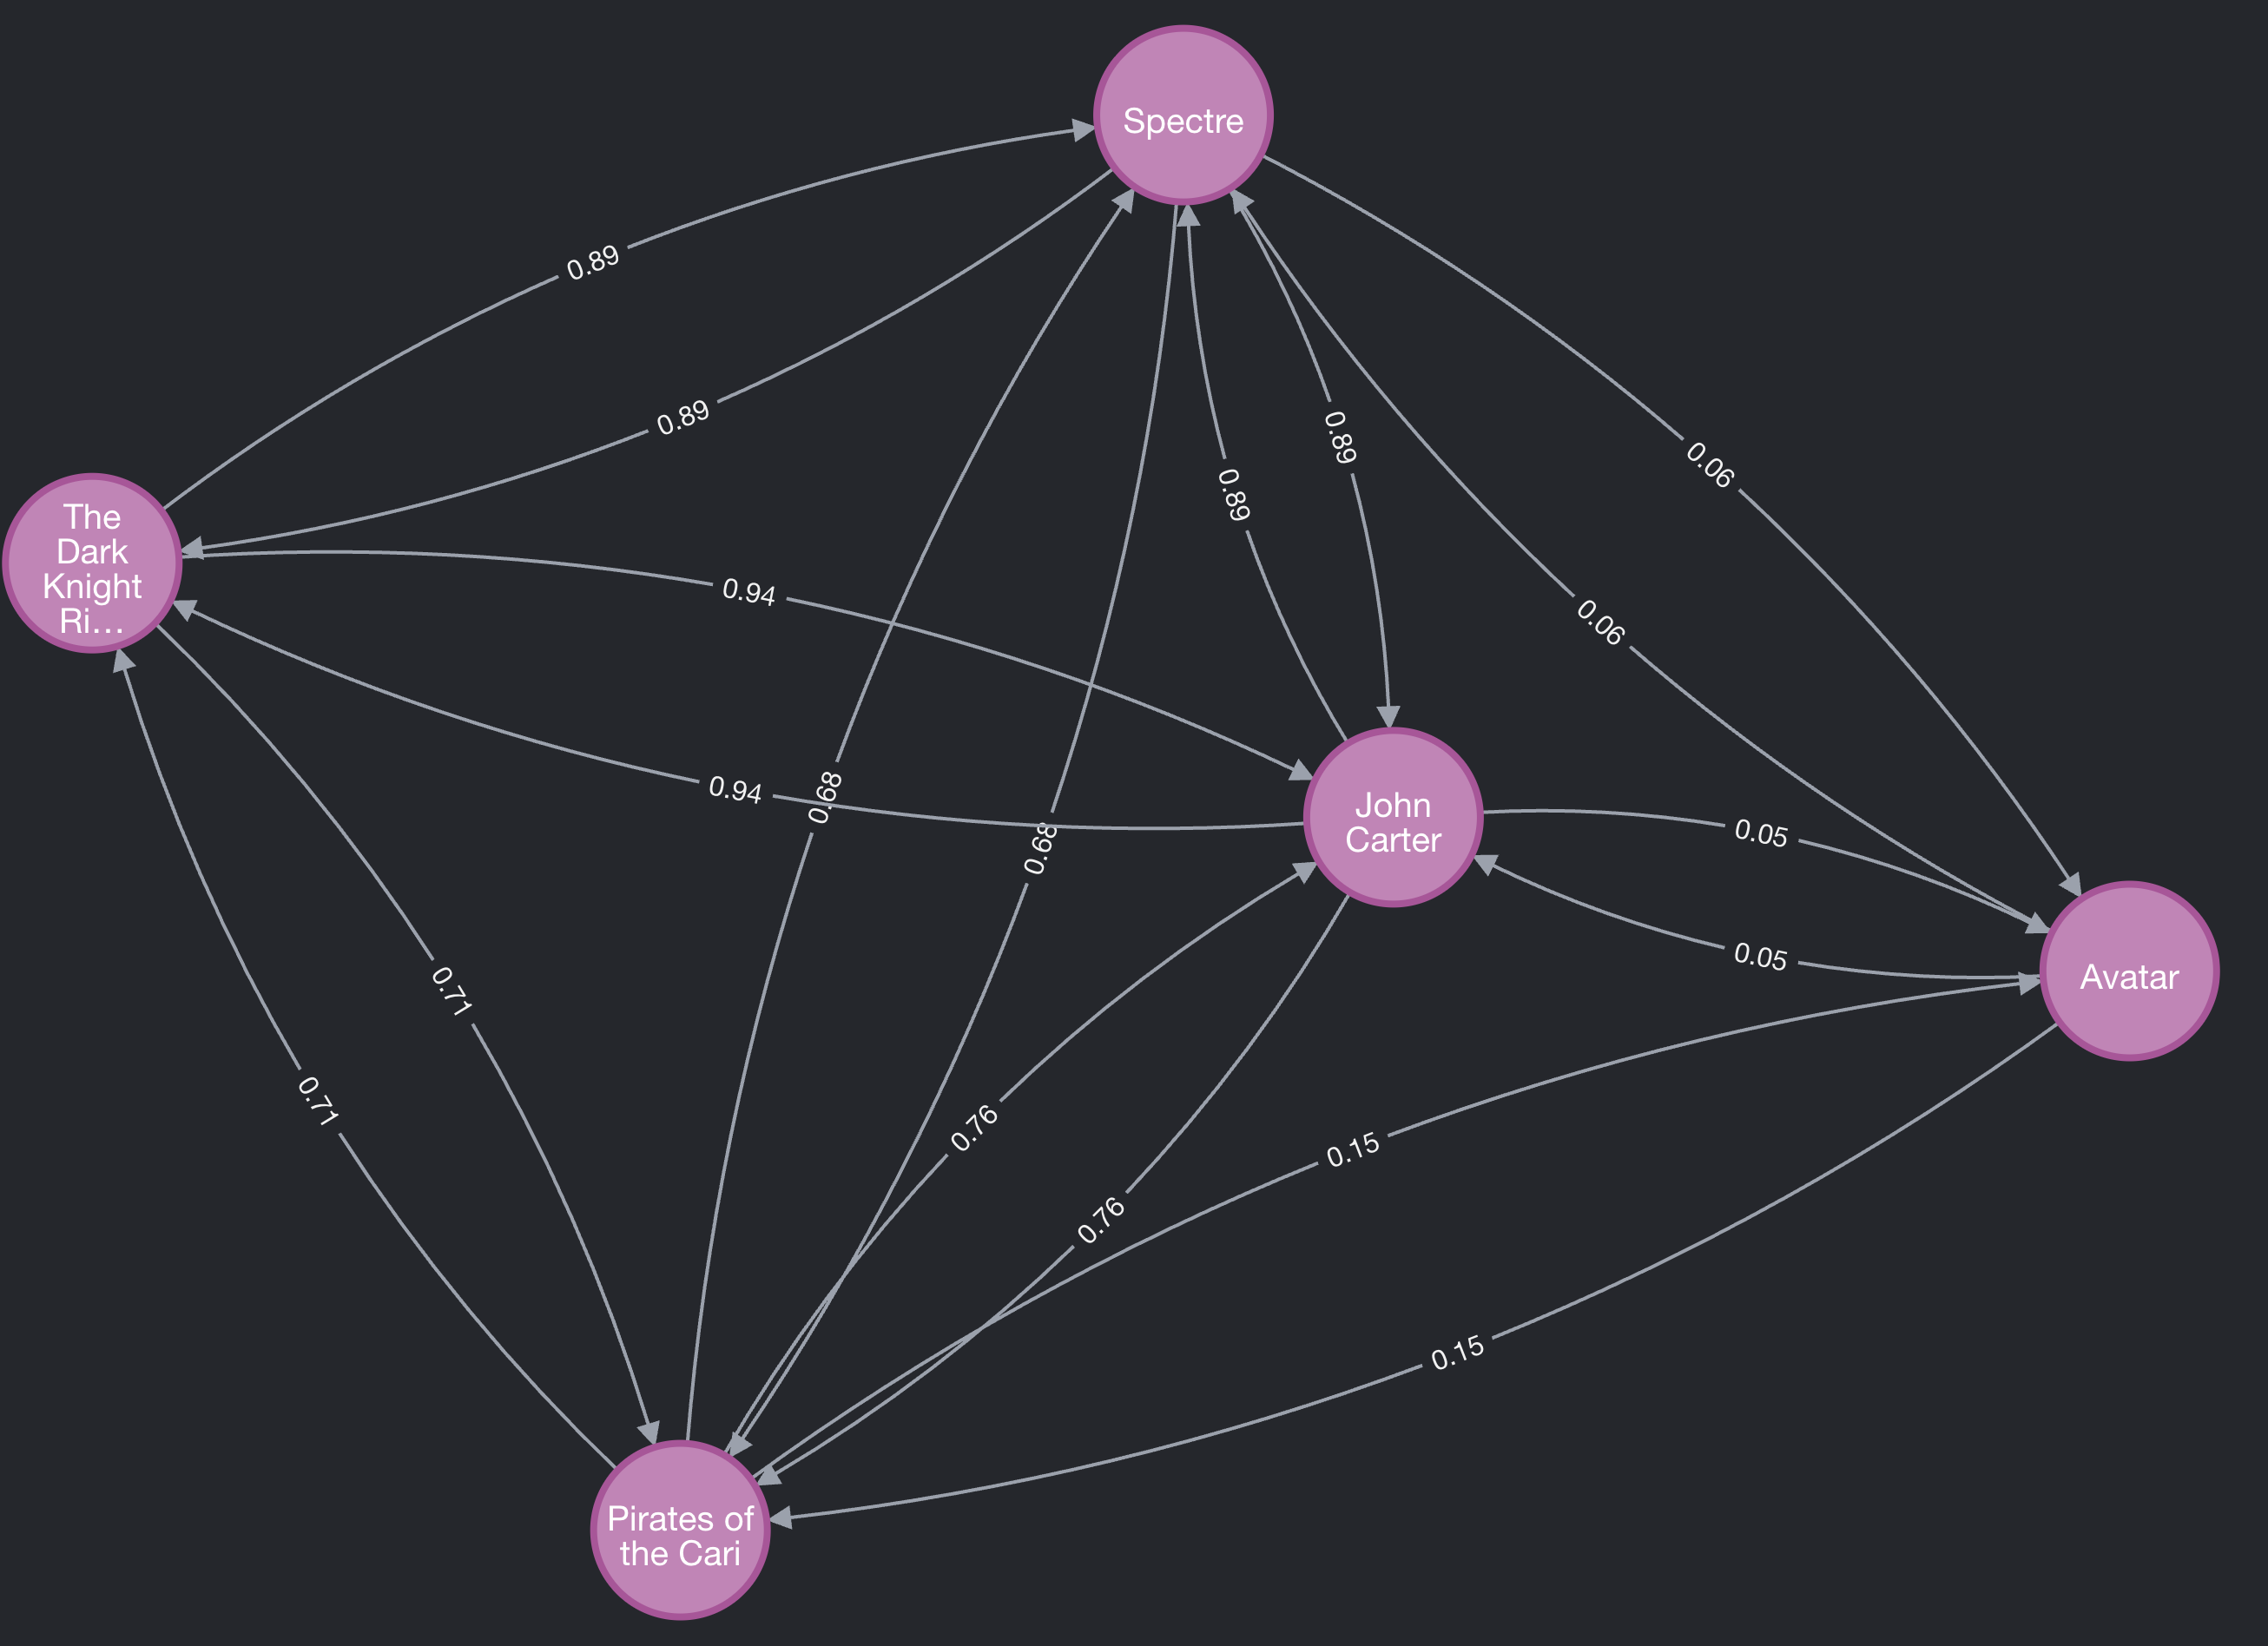

# build full graph of movies

In [12]:
# start fresh
my_neo4j_wipe_out_database()

my_neo4j_create_movie_nodes(movies_df, len(movies_df))
my_neo4j_create_top_3_similarity_links(movies_df, len(movies_df), similarities)
    
my_neo4j_nodes_relationships()

AttributeError: 'NoneType' object has no attribute 'replace'